<a href="https://colab.research.google.com/github/sleepgoat666/Academic-Color/blob/main/Deep_JSCC_SWIPT_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# 检查GPU是否可用
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
# --- 升级版模型：集成了SWIPT逻辑 ---

# Encoder 和 Decoder 类保持不变，所以我们直接定义新的主模型
class DeepJSCC_SWIPT(nn.Module):
    def __init__(self, input_dim):
        super(DeepJSCC_SWIPT, self).__init__()
        # Encoder和Decoder的定义和之前一样
        self.encoder = Encoder(input_dim)
        self.decoder = Decoder(output_dim=input_dim)

        # 定义能量收集(EH)的非线性模型参数 (来自你的MATLAB代码)
        self.P_sat = 10.71e-5
        self.a1 = 0.8963
        self.a2 = 0.6614
        self.sa = 1 / (1 + np.exp(self.a1 * self.a2))

    def forward(self, source_data, snr_db, alpha):
        # 1. 编码
        encoded_signal = self.encoder(source_data)

        # 2. 功率归一化 (保证平均发射功率为1)
        avg_power = torch.mean(torch.sum(encoded_signal**2, dim=1))
        # 添加一个小的eps防止除以0
        normalized_signal = encoded_signal / torch.sqrt(avg_power + 1e-8)

        # 3. --- SWIPT核心逻辑 ---
        # 3a. 信号经过信道，并进行功率分割
        snr_linear = 10**(snr_db / 10.0)
        noise_var = 1.0 / snr_linear
        noise = torch.sqrt(torch.tensor(noise_var, device=self.encoder.net[0].weight.device)) * torch.randn_like(normalized_signal)

        # 用于信息解码 (ID) 的信号，功率为 alpha
        received_signal_for_id = torch.sqrt(torch.tensor(alpha)) * normalized_signal + noise

        # 用于能量收集 (EH) 的信号，功率为 (1 - alpha)
        # 注意：这里我们假设噪声对能量收集的贡献可以忽略，只考虑信号部分
        signal_for_eh = torch.sqrt(torch.tensor(1.0 - alpha)) * normalized_signal

        # 4. 解码
        decoded_data = self.decoder(received_signal_for_id)

        # 5. 计算收集到的能量
        power_in_eh = torch.mean(torch.sum(signal_for_eh**2, dim=1))
        # 使用非线性模型计算实际收集到的能量
        harvested_power_raw = self.P_sat / (1 + torch.exp(-self.a1 * (power_in_eh - self.a2)))
        # 归一化处理 (同MATLAB代码)
        harvested_power = (harvested_power_raw - self.P_sat * self.sa) / (1 - self.sa)

        # 返回三个值: 恢复的数据, 信息传输损失(方便后续计算), 收集到的能量
        return decoded_data, nn.MSELoss()(decoded_data, source_data), harvested_power

In [32]:
# --- 全新的训练循环：使用复合损失函数 ---

# --- 设置超参数 ---
INPUT_DIM = 20
TRAINING_SNR_DB = 7
LEARNING_RATE = 0.001
NUM_EPOCHS = 100
BATCH_SIZE = 2048 # 使用更大的批次大小让曲线更平滑
NUM_BATCHES = 500

# --- SWIPT相关超参数 (这是创新的关键！) ---
ALPHA = 0.5  # 功率分割因子：50%用于信息，50%用于能量
K_loss = 0.01 # 复合损失的权重：平衡信息和能量的重要性

# --- 初始化新模型、优化器 ---
model = DeepJSCC_SWIPT(INPUT_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# StepLR: 每隔step_size个epoch，将学习率乘以gamma
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

# --- 存储历史数据，用于绘图 ---
loss_history = []
info_loss_history = []
energy_history = []

# --- 开始训练循环 ---
print("Starting SWIPT training...")
for epoch in range(NUM_EPOCHS):
    total_loss, total_info_loss, total_energy = 0, 0, 0

    for batch_idx in range(NUM_BATCHES):
        # 1. 生成一批随机源数据
        source_data = torch.randn(BATCH_SIZE, INPUT_DIM).to(device)

        # 2. 前向传播 (传入alpha)
        decoded_data, info_loss, harvested_energy = model(source_data, TRAINING_SNR_DB, ALPHA)

        # 3. --- 计算复合损失函数 ---
        # 能量损失 = 负的收集能量 (因为我们要最大化能量)
        energy_loss = -harvested_energy

        # 复合损失 = 信息损失 + k * 能量损失
        total_loss_batch = info_loss + K_loss * energy_loss

        # 4. 反向传播和优化
        optimizer.zero_grad()
        total_loss_batch.backward()
        optimizer.step()

        # 记录各项数据
        total_loss += total_loss_batch.item()
        total_info_loss += info_loss.item()
        total_energy += harvested_energy.item()

    # 记录并打印每轮的平均值
    avg_loss = total_loss / NUM_BATCHES
    avg_info_loss = total_info_loss / NUM_BATCHES
    avg_energy = total_energy / NUM_BATCHES

    loss_history.append(avg_loss)
    info_loss_history.append(avg_info_loss)
    energy_history.append(avg_energy)

    # 在每个epoch结束时，更新学习率
    scheduler.step()

    if (epoch + 1) % 10 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Total Loss: {avg_loss:.6f}, Info Loss (MSE): {avg_info_loss:.6f}, Harvested Energy: {avg_energy:.6f}, LR: {current_lr:.6f}")

print("Training finished!")

Starting SWIPT training...


KeyboardInterrupt: 

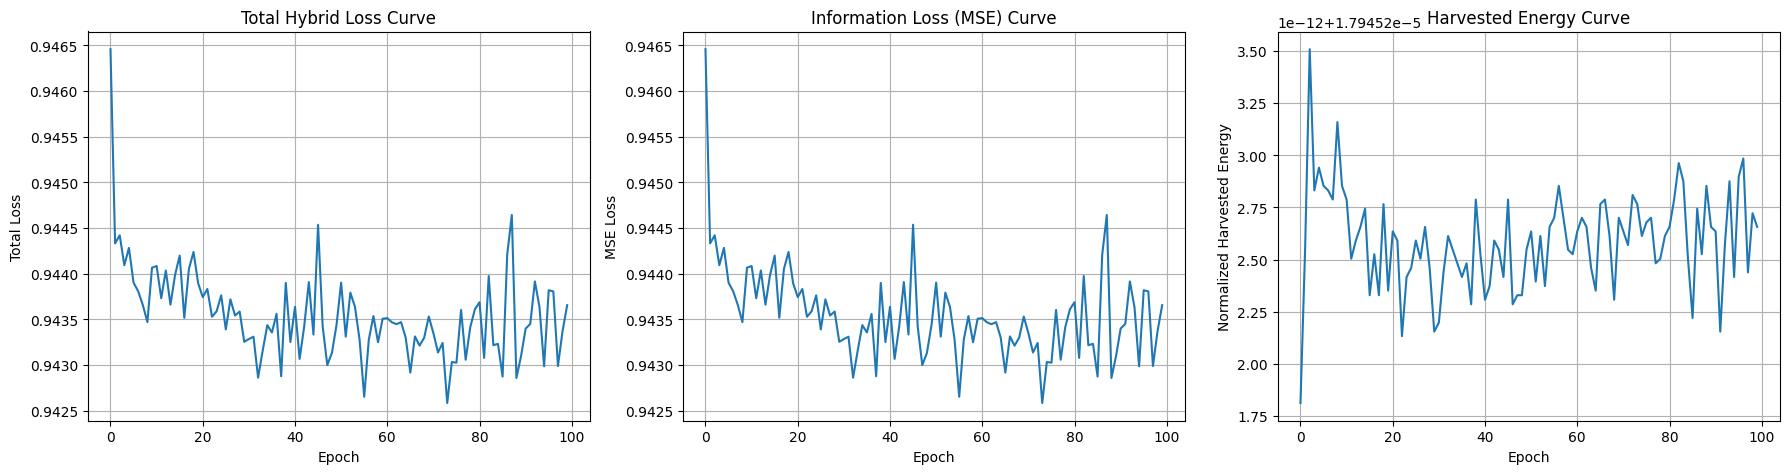

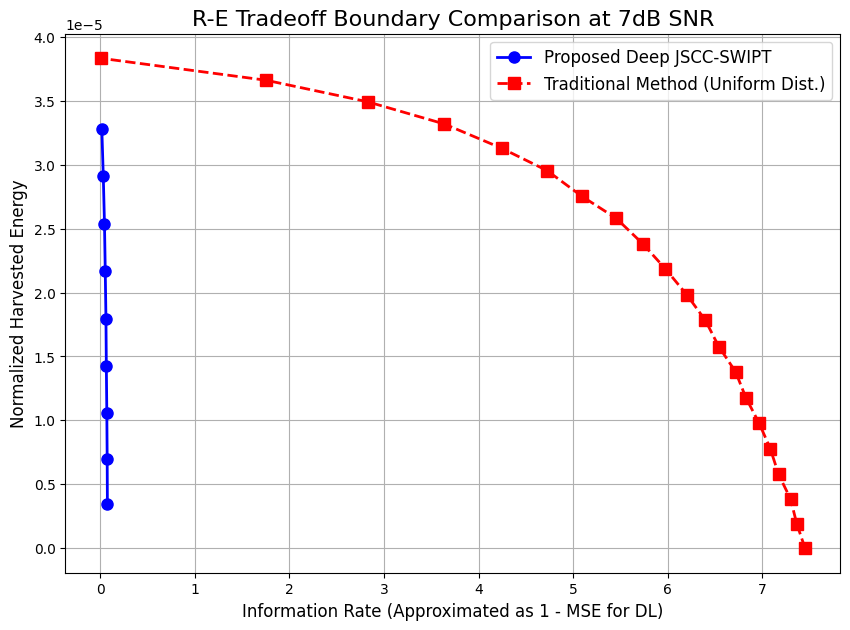


Evaluating R-E tradeoff boundary...
Alpha: 0.1 -> Rate: 0.0210, Energy: 0.000033
Alpha: 0.2 -> Rate: 0.0357, Energy: 0.000029
Alpha: 0.3 -> Rate: 0.0473, Energy: 0.000025
Alpha: 0.4 -> Rate: 0.0553, Energy: 0.000022
Alpha: 0.5 -> Rate: 0.0630, Energy: 0.000018
Alpha: 0.6 -> Rate: 0.0687, Energy: 0.000014
Alpha: 0.7 -> Rate: 0.0730, Energy: 0.000011
Alpha: 0.8 -> Rate: 0.0760, Energy: 0.000007
Alpha: 0.9 -> Rate: 0.0798, Energy: 0.000003


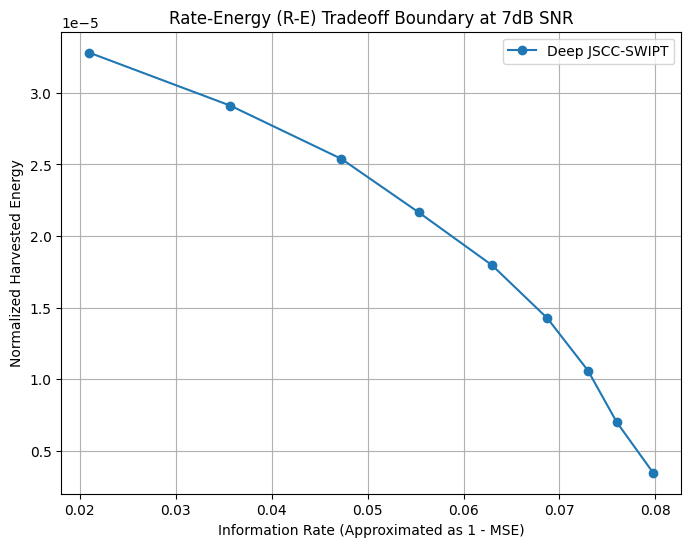

In [31]:
# --- 新的可视化代码 ---

matlab_rate_points = [7.45514235863872	,7.36822041504204	,7.30186853086539	,7.17473425063272	,7.08713097470127	,6.96938194701539
                      ,6.82976603488693	,6.71951321652220	,6.54235182619525	,6.39941957323208	,6.20321689916883
                      ,5.97565192354913	,5.74036495536505	,5.45767984873246	,5.09297689670536	,4.72662974638971
                      ,4.24695866625508	,3.63678562351292	,2.82842451899070	,1.75391299763097	,0.000445638209718076]

matlab_energy_points = [0	,1.89324988237764e-06	,3.84708061229335e-06	,5.78412280342313e-06	,7.79519542676152e-06	,9.77762677982230e-06
                        ,1.17664385484040e-05	,1.38074419276031e-05	,1.57773841267812e-05	,1.78381568198601e-05	,1.98321723803575e-05
                        ,2.18698890827157e-05	,2.37980587263970e-05	,2.58043499224338e-05	,2.75343385028643e-05	,2.95360724910558e-05
                        ,3.12836710991103e-05	,3.31910651233270e-05	,3.49199596604334e-05	,3.66069177541726e-05	,3.83309464260945e-05]
# 1. 绘制训练过程中的各项指标变化
plt.figure(figsize=(18, 5))

# 图1: 总损失
plt.subplot(1, 3, 1)
plt.plot(loss_history)
plt.title("Total Hybrid Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.grid(True)

# 图2: 信息损失 (MSE)
plt.subplot(1, 3, 2)
plt.plot(info_loss_history)
plt.title("Information Loss (MSE) Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)

# 图3: 收集能量
plt.subplot(1, 3, 3)
plt.plot(energy_history)
plt.title("Harvested Energy Curve")
plt.xlabel("Epoch")
plt.ylabel("Normalized Harvested Energy")
plt.grid(True)

plt.tight_layout()
plt.show()

# --- 绘制最终的R-E边界对比图 ---
plt.figure(figsize=(10, 7)) # 把图调大一点，更清晰

# 绘制你的深度学习方案的结果 (蓝色线)
plt.plot(rate_points, energy_points, 'o-', label='Proposed Deep JSCC-SWIPT', color='blue', linewidth=2, markersize=8)

# 绘制传统方案的结果 (红色虚线)
plt.plot(matlab_rate_points, matlab_energy_points, 's--', label='Traditional Method (Uniform Dist.)', color='red', linewidth=2, markersize=8)

# --- 美化图表 ---
plt.title(f'R-E Tradeoff Boundary Comparison at {TRAINING_SNR_DB}dB SNR', fontsize=16)
plt.xlabel('Information Rate (Approximated as 1 - MSE for DL)', fontsize=12)
plt.ylabel('Normalized Harvested Energy', fontsize=12)
plt.grid(True)
plt.legend(fontsize=12)
plt.show()

# 2. --- 绘制R-E边界图 (这是最终论文需要的核心图) ---
print("\nEvaluating R-E tradeoff boundary...")
model.eval() # 切换到评估模式

alpha_range = np.linspace(0.1, 0.9, 9) # alpha从0.1到0.9取9个点
rate_points = []
energy_points = []

# 生成固定的测试数据集，保证评估的公平性
test_source_data = torch.randn(10000, INPUT_DIM).to(device)

with torch.no_grad(): # 在评估阶段不计算梯度
    for alpha_eval in alpha_range:
        # 使用训练好的模型在不同的alpha下进行评估
        _, info_loss_eval, harvested_energy_eval = model(test_source_data, TRAINING_SNR_DB, alpha_eval)

        # 信息速率 R 可以近似为 1 - MSE
        # 这是一个常用的近似指标，更精确的需要用互信息估计
        rate_approx = 1.0 - info_loss_eval.item()

        rate_points.append(rate_approx)
        energy_points.append(harvested_energy_eval.item())
        print(f"Alpha: {alpha_eval:.1f} -> Rate: {rate_approx:.4f}, Energy: {harvested_energy_eval.item():.6f}")

# 绘制R-E边界图
plt.figure(figsize=(8, 6))
plt.plot(rate_points, energy_points, 'o-', label='Deep JSCC-SWIPT')
plt.title(f'Rate-Energy (R-E) Tradeoff Boundary at {TRAINING_SNR_DB}dB SNR')
plt.xlabel('Information Rate (Approximated as 1 - MSE)')
plt.ylabel('Normalized Harvested Energy')
plt.grid(True)
plt.legend()
plt.show()